<a href="https://colab.research.google.com/github/kalxdoc/Research_pac1/blob/main/DS422_Lab_report_1_ID_490.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS422 – Lab 1: Linear Regression & Gradient Descent
(Study Hours vs Exam Score).



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
# Study hours vs exam score dataset (20 samples)
data = {
    "Hours_Studied": [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10],
    "Exam_Score":    [30, 35, 38, 40, 46, 50, 52, 55, 58, 60, 63, 65, 68, 70, 74, 75, 80, 85, 90, 95]
}
df = pd.DataFrame(data)
df

,Hours_Studied,Exam_Score
0,0.5,30
1,1.0,35
2,1.5,38
3,2.0,40
4,2.5,46
5,3.0,50
6,3.5,52
7,4.0,55
8,4.5,58
9,5.0,60


### Figure 1 – Dataset scatter plot

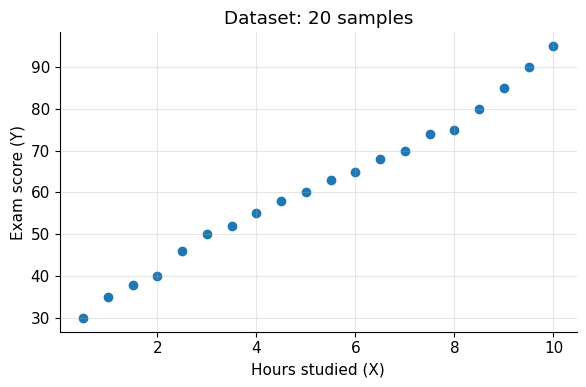

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["Hours_Studied"], df["Exam_Score"], c="tab:blue")
ax.set(xlabel="Hours studied (X)", ylabel="Exam score (Y)", title="Dataset: 20 samples")
ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig("fig1_dataset.png", dpi=200)
plt.show()

## Part 1: Linear Regression (scikit-learn)

In [4]:
X = df[["Hours_Studied"]]   # feature
y = df["Exam_Score"]        # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print("Model Training Complete!")
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

Model Training Complete!
Slope (m): 6.231337656462072
Intercept (c): 29.06183079475192


In [5]:
y_pred = model.predict(X_test)
results = pd.DataFrame({"Hours": X_test.values.ravel(), "Actual": y_test.values, "Predicted": y_pred})
results

,Hours,Actual,Predicted
0,0.5,30,32.177500
1,9.0,85,85.143870
2,8.0,75,78.912532
3,1.0,35,35.293168


In [6]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 5.039014463695029
R2 Score: 0.9913073604938953


In [7]:
# Lab task: predict for 3 different inputs
new_hours = pd.DataFrame({"Hours_Studied": [3, 7.5, 9]})
new_hours["Predicted_Score"] = model.predict(new_hours)
new_hours

,Hours_Studied,Predicted_Score
0,3.0,47.755844
1,7.5,75.796863
2,9.0,85.143870


### Figure 2 – Concept of linear regression (line, slope, intercept, residuals)
Drawn with the line fitted on all 20 samples.

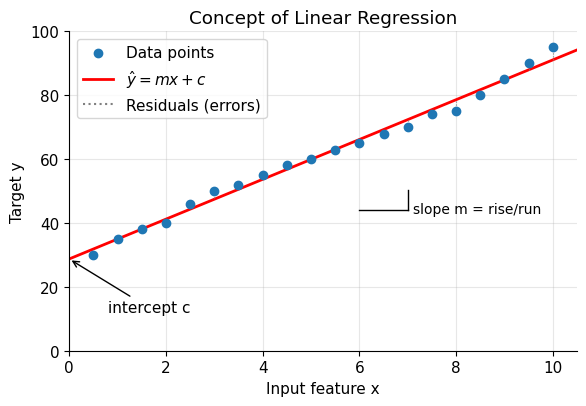

In [8]:
full = LinearRegression().fit(df[["Hours_Studied"]], df["Exam_Score"])
m, c = full.coef_[0], full.intercept_
hours = df["Hours_Studied"].values
score = df["Exam_Score"].values
xs = np.linspace(0, 10.5, 50)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(hours, score, c="tab:blue", zorder=3, label="Data points")
ax.plot(xs, m*xs + c, "r", lw=2, label=r"$\hat{y}=mx+c$")
for x, yv in zip(hours, score):
    ax.plot([x, x], [yv, m*x + c], color="gray", lw=.8, ls=":")
ax.plot([], [], color="gray", ls=":", label="Residuals (errors)")
ax.annotate("intercept c", xy=(0, c), xytext=(0.8, 12), arrowprops=dict(arrowstyle="->"))
o = -22   # draw the slope triangle below the line
ax.plot([6, 7], [m*6 + c + o]*2, "k", lw=1)
ax.plot([7, 7], [m*6 + c + o, m*7 + c + o], "k", lw=1)
ax.text(7.1, m*6.3 + c + o - 3, "slope m = rise/run", fontsize=10)
ax.set(xlabel="Input feature x", ylabel="Target y", title="Concept of Linear Regression", xlim=(0, 10.5), ylim=(0, 100))
ax.legend(loc="upper left"); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig("fig2_lr_concept.png", dpi=200)
plt.show()

### Figure 4 – Linear regression result (train/test split)

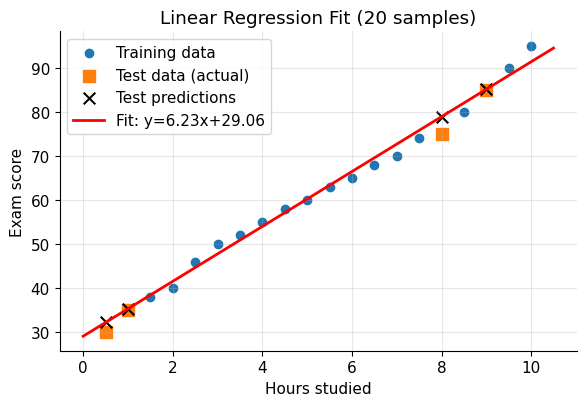

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(X_train, y_train, c="tab:blue", label="Training data")
ax.scatter(X_test, y_test, c="tab:orange", s=70, marker="s", label="Test data (actual)")
ax.scatter(X_test, y_pred, c="k", marker="x", s=70, label="Test predictions")
ax.plot(xs, model.coef_[0]*xs + model.intercept_, "r", lw=2,
        label=f"Fit: y={model.coef_[0]:.2f}x+{model.intercept_:.2f}")
ax.set(xlabel="Hours studied", ylabel="Exam score", title="Linear Regression Fit (20 samples)")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig("fig4_lr_result.png", dpi=200)
plt.show()

## Part 2: Gradient Descent (from scratch)

### Figure 3 – Concept of gradient descent
A simple 1-D loss curve J(w) = (w − 4)² to illustrate the idea (not the exam-score data).

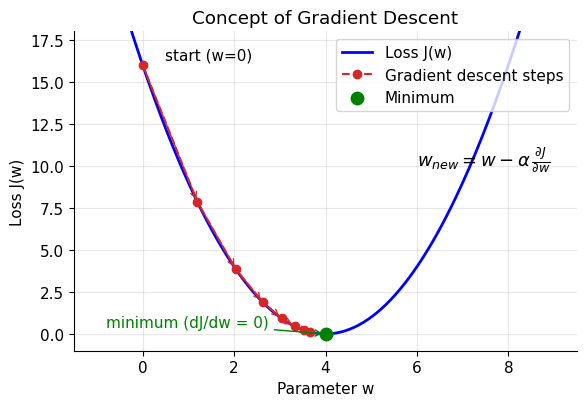

In [10]:
wv = np.linspace(-1, 9, 200)
L = (wv - 4)**2

pts = [0.0]
lr_demo = 0.15
for _ in range(7):
    pts.append(pts[-1] - lr_demo * 2 * (pts[-1] - 4))   # w = w - lr * dJ/dw
pl = [(p - 4)**2 for p in pts]

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(wv, L, "b", lw=2, label="Loss J(w)")
ax.plot(pts, pl, "o--", color="tab:red", label="Gradient descent steps")
for i in range(len(pts) - 1):
    ax.annotate("", xy=(pts[i+1], pl[i+1]), xytext=(pts[i], pl[i]),
                arrowprops=dict(arrowstyle="->", color="tab:red"))
ax.scatter([4], [0], c="green", s=80, zorder=5, label="Minimum")
ax.annotate("minimum (dJ/dw = 0)", xy=(4, 0), xytext=(-0.8, 0.4), color="green", arrowprops=dict(arrowstyle="->", color="green"))
ax.text(0.5, pl[0] + 0.3, "start (w=0)")
ax.text(6.0, 10, r"$w_{new}=w-\alpha\,\frac{\partial J}{\partial w}$", fontsize=13)
ax.set(xlabel="Parameter w", ylabel="Loss J(w)", title="Concept of Gradient Descent", ylim=(-1, 18))
ax.legend(loc="upper right"); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig("fig3_gd_concept.png", dpi=200)
plt.show()

In [11]:
X = df["Hours_Studied"].values
y = df["Exam_Score"].values

w = 0.0
b = 0.0
learning_rate = 0.01
epoch = 1000
n = len(X)
loss_history = []

In [12]:
for i in range(epoch):
    y_pred_gd = w * X + b                 # predictions
    error = y_pred_gd - y                 # error
    dw = (2/n) * np.sum(error * X)        # gradient wrt w
    db = (2/n) * np.sum(error)            # gradient wrt b
    w = w - learning_rate * dw            # update
    b = b - learning_rate * db
    loss = np.mean(error ** 2)            # MSE
    loss_history.append(loss)
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss:.3f}, w: {w:.3f}, b: {b:.3f}")

print(f"\nFinal: w = {w:.4f}, b = {b:.4f}, final loss = {loss_history[-1]:.3f}")

Epoch 0, Loss: 4102.350, w: 7.489, b: 1.229
Epoch 100, Loss: 72.446, w: 8.766, b: 11.531
Epoch 200, Loss: 31.149, w: 7.840, b: 17.813
Epoch 300, Loss: 14.515, w: 7.253, b: 21.800
Epoch 400, Loss: 7.815, w: 6.880, b: 24.331
Epoch 500, Loss: 5.116, w: 6.644, b: 25.936
Epoch 600, Loss: 4.029, w: 6.494, b: 26.956
Epoch 700, Loss: 3.591, w: 6.399, b: 27.603
Epoch 800, Loss: 3.415, w: 6.338, b: 28.013
Epoch 900, Loss: 3.344, w: 6.300, b: 28.274

Final: w = 6.2756, b = 28.4377, final loss = 3.315


### Figure 5 – Loss over epochs

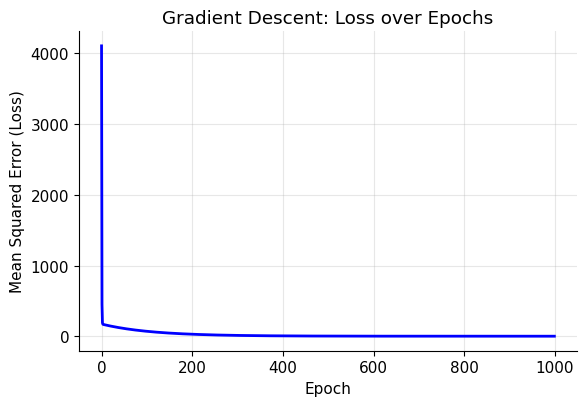

In [13]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(loss_history, "b", lw=2)
ax.set(xlabel="Epoch", ylabel="Mean Squared Error (Loss)", title="Gradient Descent: Loss over Epochs")
ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig("fig5_gd_loss.png", dpi=200)
plt.show()

### Figure 6 – Gradient descent vs scikit-learn

sklearn         : m = 6.2331, c = 28.7263
Gradient Descent: w = 6.2756, b = 28.4377


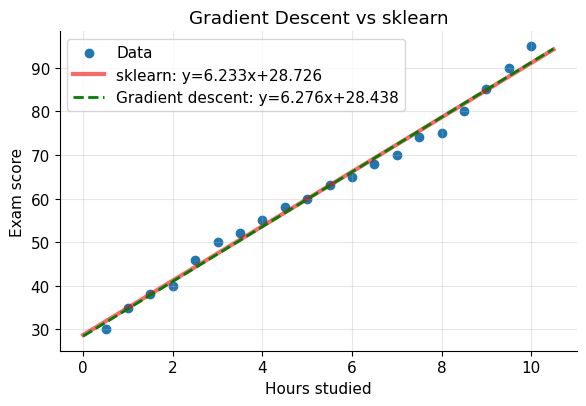

In [14]:
print("sklearn         : m = %.4f, c = %.4f" % (m, c))
print("Gradient Descent: w = %.4f, b = %.4f" % (w, b))

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(X, y, c="tab:blue", label="Data")
ax.plot(xs, m*xs + c, "r", lw=3, alpha=.6, label=f"sklearn: y={m:.3f}x+{c:.3f}")
ax.plot(xs, w*xs + b, "g--", lw=2, label=f"Gradient descent: y={w:.3f}x+{b:.3f}")
ax.set(xlabel="Hours studied", ylabel="Exam score", title="Gradient Descent vs sklearn")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig("fig6_gd_vs_sklearn.png", dpi=200)
plt.show()

## Download all report figures

In [15]:
import glob, zipfile
files = sorted(glob.glob("fig*.png"))
print("Saved figures:", files)

try:
    from google.colab import files as colab_files
    with zipfile.ZipFile("report_figures.zip", "w") as z:
        for f in files:
            z.write(f)
    colab_files.download("report_figures.zip")
except ImportError:
    print("Not running in Colab - the PNG files are in the current folder.")

Saved figures: ['fig1_dataset.png', 'fig2_lr_concept.png', 'fig3_gd_concept.png', 'fig4_lr_result.png', 'fig5_gd_loss.png', 'fig6_gd_vs_sklearn.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>